# Tutorial 2: Plotting and Advanced Options

This tutorial expands on {doc}`Tutorial 1 <tutorial_1>` with visualization and demonstrating the behavior of some key CLI options.

This tutorial assumes you have `floodsr` installed per {doc}`Tutorial 1 <tutorial_1>` and are comfortable with simple python notebooks. 
If you've never used a Jupyter notebook before, we recommend checking out the [Intro Notebooks from Project Jupyter](https://jupyter.org/try-jupyter/notebooks/?path=notebooks/Intro.ipynb) to get familiar with the interface and basic features.


There are three common ways to run this tutorial (i.e., *execution contexts*):
- **command line (CLI)**: proceed by copy/pasting the below commands from your web-browser into your terminal. NOTE for most terminals you'll need to remove the prefix `!` from each command.
- **local notebook (Jupyter)**: Use the <i class="fas fa-download"></i> button to save this notebook as an `.ipynb` file to your local machine (may need to click *save as*) and open it with your local Jupyter kernel. see {ref}`basic_install_local_notebook` for details.
- **hosted notebook (Colab)**: Use the <i class="fas fa-rocket"></i> button to open this tutorial on Google Colab.


## Install additional packages

For this tutorial, we need the additional python packages `matplotlib` and `rasterio`. Like the install of `floodsr` shown in {doc}`Tutorial 1 <tutorial_1>`, obtaining and implementing these packages depends on your execution context:

The appropriate installation steps depend on your execution context, which is described in detail in {ref}`basic_install`.
Here are the basic steps for each:
- **command line (CLI)**: first, ensure pipx is installed and on PATH, then run `pipx install floodsr`. see {ref}`basic_install_cli` for more details.
- **local notebook (Jupyter)**: same as above. then either follow the additional steps in {ref}`basic_install_local_notebook` to properly set up your environment, or be lazy and uncomment the below Jupyter cell and run.
- **hosted notebook (Colab)**: uncomment the below colab cell and run. see {ref}`basic_install_google_colab` for details.


In [1]:
# %pip install -q matplotlib rasterio

## Prove the install

Let's check the versions now:

In [2]:
!floodsr --version

floodsr 0+unknown


In [3]:
import matplotlib
import rasterio

print(f"matplotlib=={matplotlib.__version__}")
print(f"rasterio=={rasterio.__version__}")


matplotlib==3.10.8
rasterio==1.5.0


## Imports

Here we import our tools and create a small helper function for reading raster data

In [4]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
from rasterio.warp import Resampling, calculate_default_transform, reproject

In [5]:
# print cwd
print(f"Current working directory: {Path.cwd()}")

Current working directory: /home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_2-ncsVZg/run


## Download the same test data as Tutorial 1

If you already downloaded these files while working through Tutorial 1, you can skip this. 


In [6]:
urlretrieve(
    "https://github.com/cefect/floodsr/releases/download/v0.0.3/hires002_dem.tif",
    "hires002_dem.tif",
)
urlretrieve(
    "https://github.com/cefect/floodsr/releases/download/v0.0.3/lowres032.tif",
    "lowres032.tif",
)



('lowres032.tif', <http.client.HTTPMessage at 0x7a5da67f5d60>)

Here we map the downloaded paths to variables for convenience (and check that they exist)

In [7]:

lowres_fp = Path("lowres032.tif").resolve()
dem_fp = Path("hires002_dem.tif").resolve()
assert lowres_fp.is_file(), f"missing low-res raster\n    {lowres_fp}"
assert dem_fp.is_file(), f"missing DEM raster\n    {dem_fp}"


## Fetch model weights

You can skip this if you just ran Tutorial 1, but re-fetching is best-practice and harmless (if the file already exist, it won't be re-downloaded).

In [8]:
!floodsr models fetch --no-progress ResUNet_16x_DEM

version=ResUNet_16x_DEM stored=/tmp/.cache/floodsr/ResUNet_16x_DEM/model_infer.onnx retrieved_from=cache


## Plot the tutorial inputs

First, lets define a simple function to help us load raster data into the plots

In [9]:
def read_raster_band_1(fp):
    """Read band 1 as float and promote masked nodata pixels to NaN."""
    assert Path(fp).is_file(), f"missing raster\n    {fp}"
    with rasterio.open(fp) as src:
        return src.read(1, masked=True).astype(float).filled(np.nan)

Now let's plot the low-resolution flood-depth raster in blue and the DEM tile with a terrain colormap.

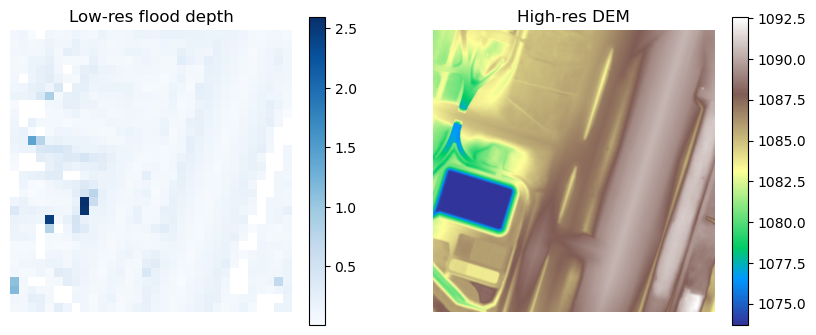

In [10]:
# Read both inputs with masked nodata promoted to NaN for plotting.
lowres_arr = read_raster_band_1(lowres_fp)
dem_arr = read_raster_band_1(dem_fp)

# setup the figure
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# add the flood raster to the left with a blue colormap, masking nodata values
im0 = axes[0].imshow(np.where(lowres_arr > 0, lowres_arr, np.nan), cmap="Blues")
axes[0].set_title("Low-res flood depth")
fig.colorbar(im0, ax=axes[0])
axes[0].set_axis_off()

# add the DEM raster to the right with a terrain colormap
im1 = axes[1].imshow(dem_arr, cmap="terrain")
axes[1].set_title("High-res DEM")
fig.colorbar(im1, ax=axes[1])
axes[1].set_axis_off()



this shows the not-so-great coarse pluvial flood raster at 32m

## Plot the tutorial 1 outputs

Now let's run the same command as Tutorial 1, to rebuild the high-resolution flood depth raster. 

In [11]:
# Run the default threshold first so we have a baseline for comparison.
!floodsr -q tohr --in lowres032.tif --dem hires002_dem.tif --out lowres032_default_sr.tif



feather pass:   0%|                                   | 0/1 [00:00<?, ?window/s]


feather pass: 100%|███████████████████████████| 1/1 [00:00<00:00, 19.61window/s]

final write pass: 100%|█████████████████| 128/128 [00:00<00:00, 10575.61block/s]
/home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_2-ncsVZg/run/lowres032_default_sr.tif


In [12]:
# Check that the expected output raster exists.
assert Path("lowres032_default_sr.tif").is_file(), "missing output raster\n    lowres032_default_sr.tif"


We can plot this with a similar pattern

Text(0.5, 1.0, 'Tutorial 1 hi-res result')

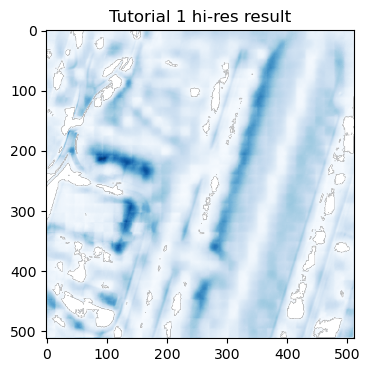

In [ ]:
ar = read_raster_band_1(Path("lowres032_default_sr.tif").resolve())

plt.figure(figsize=(5, 4))
plt.imshow(np.where(ar > 0, ar, np.nan), cmap="Blues")
_ = plt.title("Tutorial 1 hi-res result")



## Probe the CRS of both rasters

A coordinate reference system (CRS) tells raster software how pixel locations map onto real-world coordinates. Ideally, your data is all on some obvious, common CRS (e.g., NAD83(CSRS) / Canada Atlas Lambert aka [EPSG:3979](https://epsg.io/3979)), but in practice you may encounter rasters with missing or mismatched CRS information; and we need to tell `floodsr` how to handle these cases.

Before we trigger a CRS mismatch on purpose, let's inspect the CRS metadata on the original rasters.


In [14]:
with rasterio.open(lowres_fp) as src:
    print(f"{lowres_fp.name}: crs={src.crs} shape={src.shape} res={src.res}")

with rasterio.open(dem_fp) as src:
    print(f"{dem_fp.name}: crs={src.crs} shape={src.shape} res={src.res}")


lowres032.tif: crs=EPSG:3979 shape=(32, 32) res=(32.0, 32.0)
hires002_dem.tif: crs=EPSG:3979 shape=(512, 512) res=(2.0, 2.0)


Here we see that the CRS of both rasters are identical.

Nice for simple test data, but not so interesting for demonstrating how `floodsr` handles CRS mismatch. Let's mix it up.


## Create a CRS mismatch

To demonstrate `--crs-policy`, we reproject the low-resolution raster to `3978` using [rasterio CLI](https://rasterio.readthedocs.io/en/stable/cli.html) and save it as a new GeoTIFF.


In [15]:
!rio warp lowres032.tif lowres032_epsg3978.tif --dst-crs EPSG:3978 --resampling nearest --co TILED=YES

## Run `tohr` with the mismatched CRS

This command should fail because the low-resolution raster and the DEM no longer share the same CRS and we haven't told `floodsr` how to handle this mismatch yet, so it assumes `--crs-policy strict` by default. 


In [16]:
!floodsr tohr --in lowres032_epsg3978.tif --dem hires002_dem.tif


INFO:floodsr.cli:loaded ORT model 'model_infer.onnx' with providers=['CPUExecutionProvider'] and scale=16
INFO:floodsr.cli:tohr path selection
  requested_window_method=feather
  dem_float32_bytes=1,048,576
  windowed_io_threshold_bytes=33,554,432
  selected_platform_materialization=simple
ERROR:floodsr.cli:CRS mismatch under --crs-policy strict
    depth=EPSG:3978
    dem=EPSG:3979


## What `--crs-policy` does

`--crs-policy` controls how `floodsr` handles CRS mismatches between the low-resolution depth raster and the DEM. This is necessary because `tohr` needs the rasters to line up on a common projected grid before preprocessing and inference can proceed, and there is not an obvious "right answer" for which CRS to use when they don't match.

For this example we use `--crs-policy=use-dem`, which tells `floodsr` to treat the DEM CRS as the target CRS and reproject the low-resolution depth raster to match it.
We could have chosen `--crs-policy=use-lores` which would treat the low-resolution raster CRS as the target and reproject the DEM to match it.


In [17]:
!floodsr tohr --in lowres032_epsg3978.tif --dem hires002_dem.tif --crs-policy=use-dem --out lowres032_epsg3978_use_dem_sr.tif


INFO:floodsr.cli:loaded ORT model 'model_infer.onnx' with providers=['CPUExecutionProvider'] and scale=16
INFO:floodsr.cli:tohr path selection
  requested_window_method=feather
  dem_float32_bytes=1,048,576
  windowed_io_threshold_bytes=33,554,432
  selected_platform_materialization=simple


    depth=EPSG:3978
    dem=EPSG:3979
    target=EPSG:3979


INFO:floodsr.cli:starting tohr inference with model_version=ResUNet_16x_DEM
model
    /tmp/.cache/floodsr/ResUNet_16x_DEM/model_infer.onnx
platform_depth_lr
    /home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_2-ncsVZg/tmp/floodsr-platform-prep-5gyijq3y/lowres032_epsg3978_platform_depth.tif
platform_dem_hr
    /home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_2-ncsVZg/tmp/floodsr-platform-prep-5gyijq3y/hires002_dem_platform_dem.tif
output
    /home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_2-ncsVZg/run/lowres032_epsg3978_use_dem_sr.tif
INFO:floodsr.cli:platform-preprocessed inputs
  depth_lr shape=(32, 32) res=(32.0, 32.0) m/pix
  dem_hr shape=(512, 512) res=(2.0, 2.0) m/pix
INFO:floodsr.cli:model preprocessing complete
INFO:floodsr.cli:tohr execution path
  window_method=feather
  execution_path=simple
  model_space_shape=(512, 512)
  raw_output_shape=(512, 512)
INFO:floodsr.cli:prepared inputs summary:
  aligned depth_lr shape=(32, 32) res=(32.0, 32.0) m/pix
  aligned 


feather pass: 100%|███████████████████████████| 1/1 [00:00<00:00, 14.74window/s]



final write pass: 100%|██████████████████| 128/128 [00:00<00:00, 6907.85block/s]
INFO:floodsr.cli:finished tohr inference in 0.104s; wrote 1,116,817 bytes to
    /home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_2-ncsVZg/run/lowres032_epsg3978_use_dem_sr.tif
/home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_2-ncsVZg/run/lowres032_epsg3978_use_dem_sr.tif


In [18]:
# Check that the expected output raster exists.
assert Path("lowres032_epsg3978_use_dem_sr.tif").is_file(), "missing output raster\n    lowres032_epsg3978_use_dem_sr.tif"


## Plot the CRS-policy result

let's visualize the result


Text(0.5, 1.0, '`--crs-policy=use-dem` result')

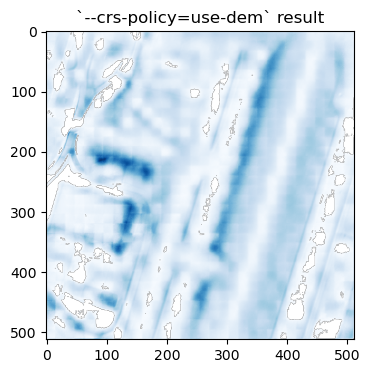

In [19]:
use_dem_fp = Path("lowres032_epsg3978_use_dem_sr.tif").resolve()
use_dem_arr = read_raster_band_1(use_dem_fp)

plt.figure(figsize=(5, 4))
plt.imshow(np.where(use_dem_arr > 0, use_dem_arr, np.nan), cmap="Blues")
plt.title("`--crs-policy=use-dem` result")



Check out the {ref}`user_faq` for more discussion on CRS policies.

## `--min-depth-threshold`

Now lets explore the argument `--min-depth-threshold`, which sets the minimum predicted depth retained in the output raster. 
Values below the threshold are written as `0.0`.

This is useful because very small positive predictions can be noisy or physically improbable, making it an important parameter for tuning the result. 

We already ran `tohr` with the default `--min-depth-threshold` (0.01) above as a baseline, so now let's run it again with a higher threshold of `0.1` for comparison.


you'll noticed we used the `-q` or `--quiet` flag to suppress the usual CLI output here.

Now let's run `tohr` with a higher `--min-depth-threshold` of `0.1`.

In [20]:
!floodsr tohr --in lowres032.tif --dem hires002_dem.tif --min-depth-threshold=0.1 --out lowres032_min_depth_01_sr.tif


INFO:floodsr.cli:loaded ORT model 'model_infer.onnx' with providers=['CPUExecutionProvider'] and scale=16
INFO:floodsr.cli:tohr path selection
  requested_window_method=feather
  dem_float32_bytes=1,048,576
  windowed_io_threshold_bytes=33,554,432
  selected_platform_materialization=simple


INFO:floodsr.cli:starting tohr inference with model_version=ResUNet_16x_DEM
model
    /tmp/.cache/floodsr/ResUNet_16x_DEM/model_infer.onnx
platform_depth_lr
    /home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_2-ncsVZg/tmp/floodsr-platform-prep-hegzbwcq/lowres032_platform_depth.tif
platform_dem_hr
    /home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_2-ncsVZg/tmp/floodsr-platform-prep-hegzbwcq/hires002_dem_platform_dem.tif
output
    /home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_2-ncsVZg/run/lowres032_min_depth_01_sr.tif
INFO:floodsr.cli:platform-preprocessed inputs
  depth_lr shape=(32, 32) res=(32.0, 32.0) m/pix
  dem_hr shape=(512, 512) res=(2.0, 2.0) m/pix
INFO:floodsr.cli:model preprocessing complete
INFO:floodsr.cli:tohr execution path
  window_method=feather
  execution_path=simple
  model_space_shape=(512, 512)
  raw_output_shape=(512, 512)
INFO:floodsr.cli:prepared inputs summary:
  aligned depth_lr shape=(32, 32) res=(32.0, 32.0) m/pix
  aligned dem_hr shape=


feather pass: 100%|███████████████████████████| 1/1 [00:00<00:00, 18.85window/s]

final write pass: 100%|█████████████████| 128/128 [00:00<00:00, 21296.80block/s]


INFO:floodsr.cli:finished tohr inference in 0.076s; wrote 160,772 bytes to
    /home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_2-ncsVZg/run/lowres032_min_depth_01_sr.tif
/home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_2-ncsVZg/run/lowres032_min_depth_01_sr.tif


In [21]:
# Check that the expected output raster exists.
assert Path("lowres032_min_depth_01_sr.tif").is_file(), "missing output raster\n    lowres032_min_depth_01_sr.tif"


## Plot

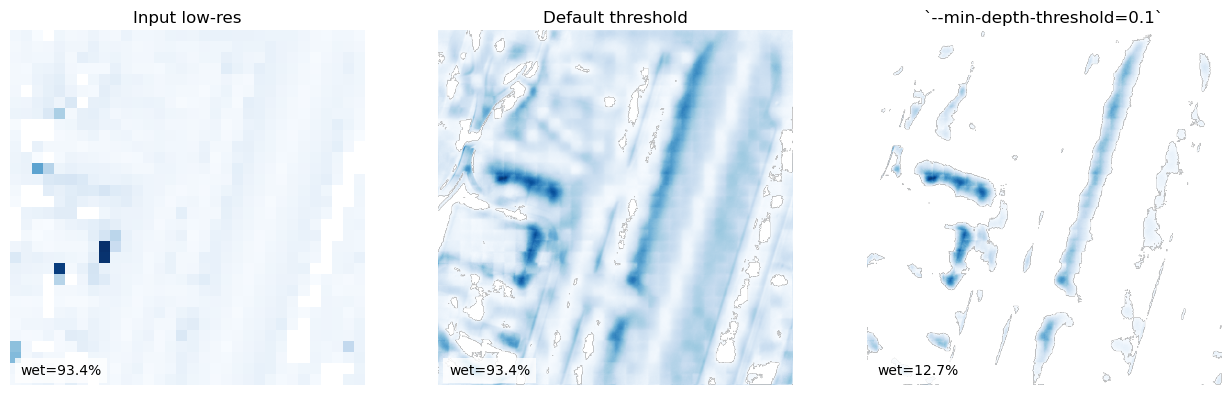

In [22]:
# Resolve the two outputs we want to compare.
default_fp = Path("lowres032_default_sr.tif").resolve()
threshold_fp = Path("lowres032_min_depth_01_sr.tif").resolve()
default_arr = read_raster_band_1(default_fp)
threshold_arr = read_raster_band_1(threshold_fp)

# Plot the input and both thresholded outputs side by side.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plot_l = [
    (axes[0], np.where(lowres_arr > 0, lowres_arr, np.nan), "Input low-res"),
    (axes[1], np.where(default_arr > 0, default_arr, np.nan), "Default threshold"),
    (axes[2], np.where(threshold_arr > 0, threshold_arr, np.nan), "`--min-depth-threshold=0.1`"),
]
for ax, arr, title in plot_l:
    wet_pct = 100.0 * float(np.count_nonzero(np.nan_to_num(arr, nan=0.0) > 0.0)) / float(arr.size)
    ax.imshow(arr, cmap="Blues")
    ax.set_title(title)
    ax.axis("off")
    ax.text(0.03, 0.03, f"wet={wet_pct:.1f}%", transform=ax.transAxes, color="black", fontsize=10, bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"})
fig.tight_layout()


## Next steps

Continue with Tutorial 3 to see how `floodsr` can operate on large rasters
